In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
mkdir -p /content/drive/MyDrive/Transfer

In [5]:
cd /content/drive/MyDrive/Transfer

/content/drive/MyDrive/Transfer


In [6]:
!wget -O imagenesvgg16.zip https://github.com/adiacla/bigdata/raw/refs/heads/master/imagenesvgg16.zip

--2026-04-08 23:54:22--  https://github.com/adiacla/bigdata/raw/refs/heads/master/imagenesvgg16.zip
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/adiacla/bigdata/refs/heads/master/imagenesvgg16.zip [following]
--2026-04-08 23:54:22--  https://raw.githubusercontent.com/adiacla/bigdata/refs/heads/master/imagenesvgg16.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 191649 (187K) [application/zip]
Saving to: ‘imagenesvgg16.zip’

imagenesvgg16.zip   100%[===================>] 187.16K  --.-KB/s    in 0.02s   

2026-04-08 23:54:22 (10.9 MB/s) - ‘imagenesvgg16.zip’ saved [191649/191649]



In [7]:
ls -lh imagenesvgg16.zip

-rw------- 1 root root 188K Apr  8 23:54 imagenesvgg16.zip


In [8]:
ls /content/drive/MyDrive/Transfer/

bus.jpg  imagenesvgg16.zip  perro.jpg  vaso.jpg


In [9]:
!unzip /content/imagenesvgg16.zip -d /content/drive/MyDrive/Transfer/

unzip:  cannot find or open /content/imagenesvgg16.zip, /content/imagenesvgg16.zip.zip or /content/imagenesvgg16.zip.ZIP.


In [10]:
# Modelo VGG16
import keras
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.applications.vgg16 import decode_predictions
from tensorflow.keras.preprocessing import image
import numpy as np

In [11]:
modelo_base = VGG16(
    weights='imagenet',   
    include_top=True      
)

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [12]:
nuevas_img = [
    "/content/drive/MyDrive/Transfer/perro.jpg",
    "/content/drive/MyDrive/Transfer/bus.jpg",
    "/content/drive/MyDrive/Transfer/vaso.jpg"
]

In [13]:
imagenes_nuevas = []

for img_path in nuevas_img:
    # Cargar imagen con tamaño 224x224
    img = image.load_img(img_path, target_size=(224, 224))
    
    # Convertir a array
    img_array = image.img_to_array(img)
    
    # Expandir dimensiones (de (224,224,3) a (1,224,224,3))
    img_array = np.expand_dims(img_array, axis=0)
    
    # Preprocesar para VGG16
    img_array = preprocess_input(img_array)
    
    # Guardar en la lista
    imagenes_nuevas.append(img_array)

In [14]:
for img in imagenes_nuevas:
    print(img.shape)

(1, 224, 224, 3)
(1, 224, 224, 3)
(1, 224, 224, 3)


In [15]:
imagenes_nuevas

[array([[[[137.061  , 130.22101, 128.32   ],
          [137.061  , 130.22101, 128.32   ],
          [137.061  , 130.22101, 128.32   ],
          ...,
          [142.061  , 132.22101, 130.32   ],
          [142.061  , 132.22101, 130.32   ],
          [142.061  , 132.22101, 130.32   ]],
 
         [[137.061  , 130.22101, 128.32   ],
          [137.061  , 130.22101, 128.32   ],
          [137.061  , 130.22101, 128.32   ],
          ...,
          [142.061  , 132.22101, 130.32   ],
          [142.061  , 132.22101, 130.32   ],
          [142.061  , 132.22101, 130.32   ]],
 
         [[137.061  , 130.22101, 128.32   ],
          [137.061  , 130.22101, 128.32   ],
          [137.061  , 130.22101, 128.32   ],
          ...,
          [142.061  , 132.22101, 130.32   ],
          [142.061  , 132.22101, 130.32   ],
          [142.061  , 132.22101, 130.32   ]],
 
         ...,
 
         [[133.061  , 129.22101, 126.32   ],
          [133.061  , 129.22101, 126.32   ],
          [133.061  , 129.2210

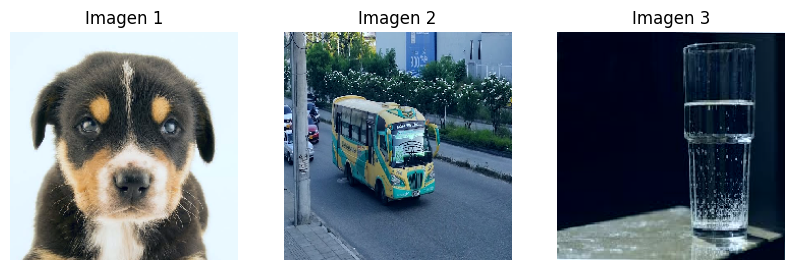

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for i, img in enumerate(imagenes_nuevas):
    plt.subplot(1, 3, i+1)
    
    # Quitar dimensión extra (1,224,224,3) → (224,224,3)
    img_mostrar = img[0]
    
    # IMPORTANTE: deshacer preprocess para que se vea bien
    img_mostrar = img_mostrar[..., ::-1]  # BGR → RGB
    img_mostrar = img_mostrar + [103.939, 116.779, 123.68]  # media de VGG16
    img_mostrar = img_mostrar / 255.0
    
    plt.imshow(img_mostrar.astype('float32'))
    plt.title(f"Imagen {i+1}")
    plt.axis('off')

plt.show()

In [17]:
from tensorflow.keras.applications.vgg16 import decode_predictions
import numpy as np

# Unir todas las imágenes en un solo batch
imagenes_nuevas = np.vstack(imagenes_nuevas)

# Hacer predicción
predicciones = modelo_base.predict(imagenes_nuevas)

# Decodificar (top 3)
resultados = decode_predictions(predicciones, top=3)

# Mostrar resultados
for i, resultado in enumerate(resultados):
    print(f"\nImagen {i+1}:")
    for _, nombre, prob in resultado:
        print(f"  {nombre}: {prob:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Imagen 1:
  Appenzeller: 0.7083
  EntleBucher: 0.1581
  Greater_Swiss_Mountain_dog: 0.0754

Imagen 2:
  minibus: 0.7823
  trolleybus: 0.0765
  moving_van: 0.0482

Imagen 3:
  beer_glass: 0.3172
  cocktail_shaker: 0.3158
  perfume: 0.1013


Transfer Learning para clasificar Perros y Gatos

In [18]:
import tensorflow as tf
import os
import matplotlib.pyplot as plt

In [19]:
import os

# Ver qué hay en la ruta donde se descargó
base_dir = os.path.dirname(dogs_cats)
print("Ruta base:", base_dir)

# Listar archivos y carpetas
for ruta, carpetas, archivos in os.walk(base_dir):
    nivel = ruta.replace(base_dir, '').count(os.sep)
    sangria = ' ' * 2 * nivel
    print(f"{sangria}{os.path.basename(ruta)}/")
    if nivel < 3:  # Solo mostrar 3 niveles de profundidad
        for archivo in archivos:
            print(f"{sangria}  {archivo}")

NameError: name 'dogs_cats' is not defined

In [ ]:
base_dir = '/root/.keras/datasets/dogs_cats/cats_and_dogs_filtered'

train_dir = os.path.join(base_dir, 'train')
val_dir   = os.path.join(base_dir, 'validation')

train_data = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(224, 224),
    batch_size=32
)

val_data = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(224, 224),
    batch_size=32
)

print(train_data.class_names)

In [ ]:
import matplotlib.pyplot as plt

nombres_clases = train_data.class_names

fig, axes = plt.subplots(6, 5, figsize=(15, 18))
axes = axes.flatten()

contador = 0
for imagenes, etiquetas in train_data:
    for i in range(len(imagenes)):
        if contador >= 30:
            break
        axes[contador].imshow(imagenes[i].numpy().astype('uint8'))
        axes[contador].set_title(nombres_clases[etiquetas[i]], fontsize=12)
        axes[contador].axis('off')
        contador += 1
    if contador >= 30:
        break

plt.suptitle('Primeras 30 Imágenes del Dataset', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()